# Inference for nonlinear dynamical systems: cholera in dynestyx

This notebook reproduces the cholera analysis of Ionides, Bretó and King,
"Inference for nonlinear dynamical systems," PNAS 103 (2006) 18438. The paper
introduced maximum likelihood via iterated filtering (MIF), a plug-and-play
method that needs only the ability to simulate the latent process and to
evaluate the measurement density. Its driving example is cholera mortality in
Dhaka, Bangladesh, modeled as a seasonally forced stochastic SIRS process with
an environmental reservoir.

The paper estimates parameters by repeatedly running a particle filter and
letting time-varying parameter perturbations drift toward the maximum
likelihood estimate. In dynestyx the same partially observed Markov process is
a `DynamicalModel` scored by a particle filter. We reproduce the two central
results on this model.

1. On simulated data generated at the paper's Table 1 parameters, the
   particle-filter likelihood is maximized at the generating values. We show
   this through profile likelihoods over the seasonal amplitude, the
   environmental noise, and the reservoir strength, matching the paper's
   Figs. 3 and 4.
2. The same likelihood supports Bayesian inference. A particle marginal
   Metropolis-Hastings sampler returns a posterior over the environmental
   noise and the measurement overdispersion that covers the truth.

We then load the historical Dhaka series and show that the Table 1 parameters
generate epidemics of the right magnitude and seasonal shape.

## The model

The population is divided into susceptible $S$, infected $I$, and $k$ recovered
classes $R^1, \dots, R^k$. The recovered classes give a gamma-distributed
immune period with mean $1/r$ and shape $k$. The transitions follow the
stochastic differential equations of the paper (its Eqs. 3 and 4), with all
rates per month,

$$
\mathrm{d}N^{SI} = \lambda(t)\, S\, \mathrm{d}t + \varepsilon \frac{I}{P} S\, \mathrm{d}W,
\qquad
\lambda(t) = \beta(t)\frac{I}{P} + \omega .
$$

The force of infection has a human-to-human term $\beta(t) I / P$ and a
constant environmental reservoir term $\omega$. Transmission is seasonal,

$$
\log \beta(t) = \sum_{j=0}^{5} b_j\, s_j(t),
$$

where the $s_j$ are a periodic cubic B-spline basis over the year. The
environmental noise $\varepsilon$ enters only the $S \to I$ channel and gives
an infinitesimal variance proportional to $S^2$. The remaining transitions
(recovery, progression through immune classes, loss of immunity, births, and
the three death channels) are deterministic.

Observations are monthly cholera deaths. Writing $\Delta C_t$ for the deaths
accrued over month $t$, the measurement model is

$$
y_t \sim \mathcal{N}\!\left(\Delta C_t,\; \tau^2 \Delta C_t^2\right).
$$

The latent vector carried by the filter is
$z = [S, I, R^1, R^2, R^3, M]$, where $M$ holds the cholera deaths over the
most recent interval. Each monthly transition runs twenty Euler-Maruyama
substeps and recomputes $M$ from zero, so the death accumulator resets every
observation without any special framework support. The transition is a custom
NumPyro distribution whose `sample` integrates the SDE; the bootstrap particle
filter proposes from it and scores with the measurement density, so no
transition density is ever needed.

In [1]:
import time

import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np

jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt

from cholera import THETA_STAR, transmission_rate, K_CLASSES
from seasonal import periodic_bspline_basis
import inference as inf

# The Table 1 generating parameters of the paper.
for name, val in THETA_STAR._asdict().items():
    print(f"{name:6s} {np.array(val)}")

b      [-0.58  4.73 -5.76  2.37  1.69  2.56]
omega  0.000176
eps    0.8
gamma  1.3333333333333333
m_c    0.046
m      0.0016666666666666668
r      0.008333333333333333
tau    0.25


## Seasonal transmission

The six periodic B-splines form a nonnegative partition of unity over the
year. The Table 1 coefficients turn them into the seasonal transmission curve
$\beta(t)$, which peaks before the monsoon.

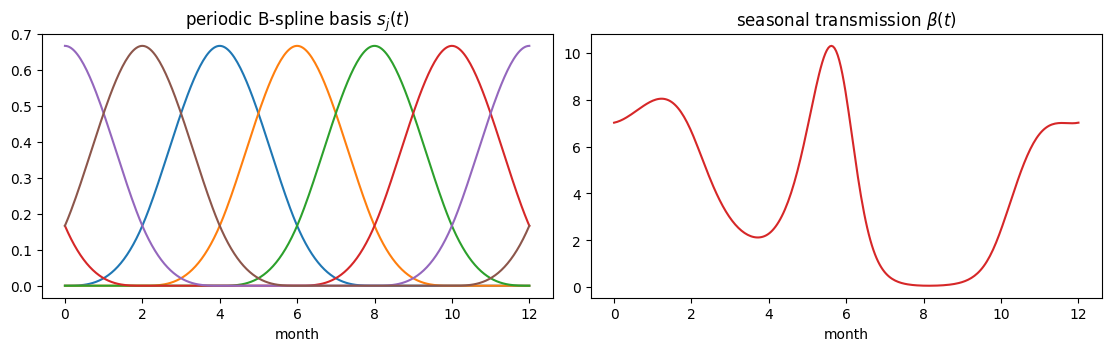

In [2]:
months = jnp.linspace(0.0, 12.0, 300)
basis = periodic_bspline_basis(months, nbasis=6, degree=3, period=12.0)
beta = transmission_rate(months, THETA_STAR.b)

fig, axs = plt.subplots(1, 2, figsize=(11, 3.4), constrained_layout=True)
for j in range(6):
    axs[0].plot(months, basis[:, j])
axs[0].set_title("periodic B-spline basis $s_j(t)$")
axs[0].set_xlabel("month")
axs[1].plot(months, beta, color="C3")
axs[1].set_title(r"seasonal transmission $\beta(t)$")
axs[1].set_xlabel("month")
plt.show()

## Simulating the model

We draw one trajectory at the Table 1 parameters over twenty years with a
fixed population. This is the analog of the paper's Fig. 2A. The monthly death
series shows sharp annual epidemics, and the susceptible fraction cycles in the
range the paper reports.

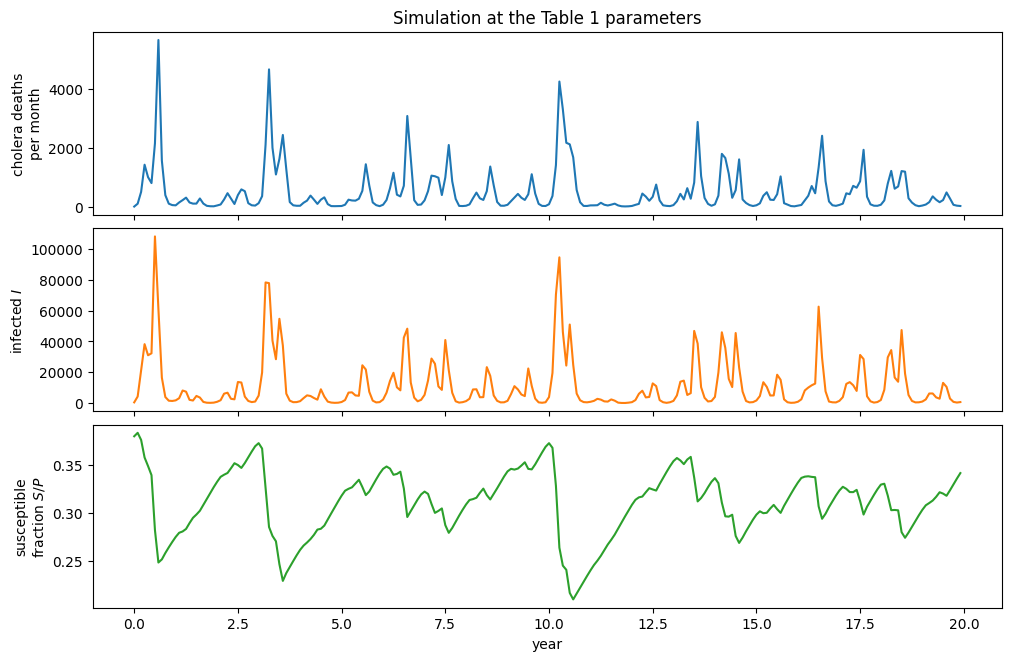

deaths per month: mean 510, max 5673
susceptible fraction range: 0.21 to 0.38


In [3]:
N_MONTHS = 240
P0 = 2.42e6
times, ctrl, obs, states = inf.simulate(THETA_STAR, n_months=N_MONTHS, P0=P0, key=jr.PRNGKey(0))

years = times / 12.0
fig, axs = plt.subplots(3, 1, figsize=(10, 6.5), sharex=True, constrained_layout=True)
axs[0].plot(years, obs, color="C0")
axs[0].set_ylabel("cholera deaths\nper month")
axs[1].plot(years, states[:, 1], color="C1")
axs[1].set_ylabel("infected $I$")
axs[2].plot(years, states[:, 0] / P0, color="C2")
axs[2].set_ylabel("susceptible\nfraction $S/P$")
axs[2].set_xlabel("year")
axs[0].set_title("Simulation at the Table 1 parameters")
plt.show()

print("deaths per month: mean %.0f, max %.0f" % (float(obs.mean()), float(obs.max())))
print("susceptible fraction range: %.2f to %.2f" % (
    float((states[:, 0] / P0).min()), float((states[:, 0] / P0).max())))

## The particle-filter likelihood

Conditioning the model on the observations and wrapping it in a particle
filter integrates out the latent states and returns the marginal
log-likelihood. This single number is what iterated filtering maximizes. Each
evaluation simulates particle trajectories and weights them by the measurement
density, so it needs nothing beyond the model we already wrote.

In [4]:
z0 = inf.default_initial_state(P0)
ll_star = inf.marginal_loglik(
    **inf.free_params(THETA_STAR),
    obs_times=times, obs_values=obs, ctrl_values=ctrl, z0=z0,
    key=jr.PRNGKey(1), n_particles=800,
)
print("marginal log-likelihood at the generating parameters: %.1f" % float(ll_star))

marginal log-likelihood at the generating parameters: -1366.2


## Profile likelihoods recover the parameters

We sweep one parameter at a time, holding the rest at the generating values,
and read off the maximizing value. A fixed filter seed (common random numbers)
makes the curve smooth enough to locate the peak. The argmax sits at the
generating parameter in each case, reproducing the sliced likelihoods of the
paper's Fig. 3.

profiling time 12.4s


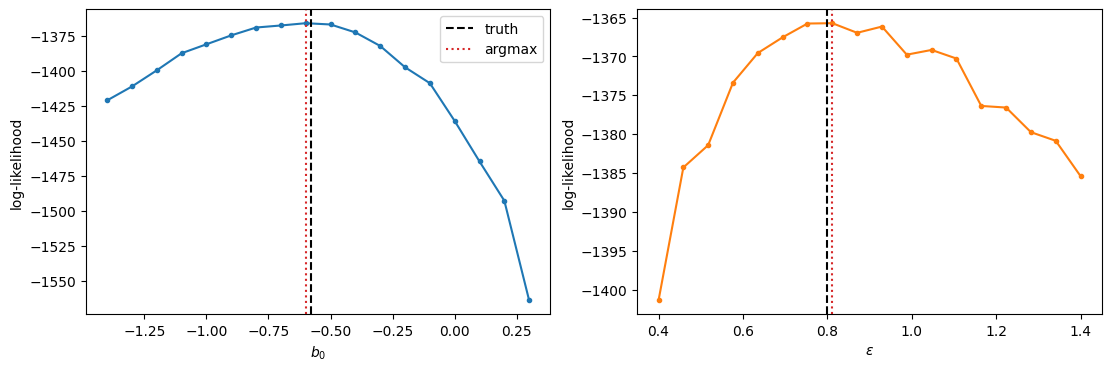

b0  : argmax -0.60, truth -0.58
eps : argmax 0.81, truth 0.80


In [5]:
b0_grid = jnp.linspace(-1.4, 0.3, 18)
eps_grid = jnp.linspace(0.4, 1.4, 18)

t0 = time.time()
ll_b0 = inf.profile("b0", b0_grid, THETA_STAR,
                    obs_times=times, obs_values=obs, ctrl_values=ctrl, z0=z0,
                    key=jr.PRNGKey(3), n_particles=500)
ll_eps = inf.profile("eps", eps_grid, THETA_STAR,
                     obs_times=times, obs_values=obs, ctrl_values=ctrl, z0=z0,
                     key=jr.PRNGKey(3), n_particles=500)
print("profiling time %.1fs" % (time.time() - t0))

b0_hat = float(b0_grid[jnp.argmax(ll_b0)])
eps_hat = float(eps_grid[jnp.argmax(ll_eps)])

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
axs[0].plot(b0_grid, ll_b0, "o-", ms=3)
axs[0].axvline(float(THETA_STAR.b[0]), color="k", ls="--", label="truth")
axs[0].axvline(b0_hat, color="C3", ls=":", label="argmax")
axs[0].set_xlabel("$b_0$"); axs[0].set_ylabel("log-likelihood"); axs[0].legend()
axs[1].plot(eps_grid, ll_eps, "o-", ms=3, color="C1")
axs[1].axvline(float(THETA_STAR.eps), color="k", ls="--")
axs[1].axvline(eps_hat, color="C3", ls=":")
axs[1].set_xlabel(r"$\varepsilon$"); axs[1].set_ylabel("log-likelihood")
plt.show()

print("b0  : argmax %.2f, truth %.2f" % (b0_hat, float(THETA_STAR.b[0])))
print("eps : argmax %.2f, truth %.2f" % (eps_hat, float(THETA_STAR.eps)))

A local quadratic fit to the profile gives a standard error from the
curvature, the cheap alternative to the bootstrap that the paper recommends.

In [6]:
def curvature_se(grid, ll):
    g = np.array(grid); l = np.array(ll)
    c = np.polyfit(g, l, 2)
    xhat = -c[1] / (2 * c[0])
    se = float(np.sqrt(-1.0 / (2 * c[0]))) if c[0] < 0 else np.nan
    return xhat, se

eps_hat_q, eps_se = curvature_se(eps_grid, ll_eps)
print("eps quadratic peak %.2f, curvature SE %.2f (paper SE 0.06)" % (eps_hat_q, eps_se))

eps quadratic peak 0.92, curvature SE 0.07 (paper SE 0.06)


## Evidence for the environmental reservoir

The reservoir term $\omega$ is the paper's main scientific question (its
Fig. 4). On data simulated with $\omega = 1.76 \times 10^{-4}$, the profile
likelihood over $\omega$ peaks at a strictly positive value and falls off as
$\omega \to 0$. The drop is the likelihood-ratio evidence for a non-human
reservoir, here validated where the truth is known.

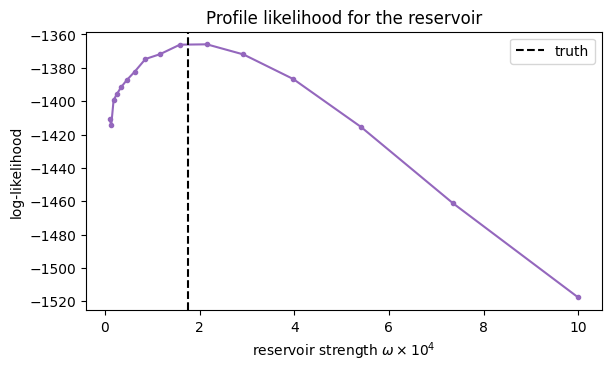

omega argmax 2.15e-04 (truth 1.76e-4)
log-likelihood drop from peak to omega=1e-5: 45.0


In [7]:
lom_grid = jnp.log(10.0 ** jnp.linspace(-5.0, -3.0, 16))
ll_om = inf.profile("log_omega", lom_grid, THETA_STAR,
                    obs_times=times, obs_values=obs, ctrl_values=ctrl, z0=z0,
                    key=jr.PRNGKey(3), n_particles=500)
om_grid = jnp.exp(lom_grid)
om_hat = float(om_grid[jnp.argmax(ll_om)])

fig, ax = plt.subplots(figsize=(6, 3.6), constrained_layout=True)
ax.plot(om_grid * 1e4, ll_om, "o-", ms=3, color="C4")
ax.axvline(float(THETA_STAR.omega) * 1e4, color="k", ls="--", label="truth")
ax.set_xlabel(r"reservoir strength $\omega \times 10^{4}$")
ax.set_ylabel("log-likelihood")
ax.set_title("Profile likelihood for the reservoir")
ax.legend()
plt.show()

drop = float(jnp.max(ll_om) - ll_om[0])
print("omega argmax %.2e (truth 1.76e-4)" % om_hat)
print("log-likelihood drop from peak to omega=1e-5: %.1f" % drop)

## Bayesian inference with particle marginal Metropolis-Hastings

The particle filter returns an unbiased likelihood estimate, so a random-walk
Metropolis sampler that accepts on that estimate targets the exact posterior.
This is the pseudo-marginal method. We sample the environmental noise
$\varepsilon$ and the measurement overdispersion $\tau$, holding the other
parameters fixed. The posterior concentrates around the generating values.

PMMH time 248.3s, acceptance 0.29


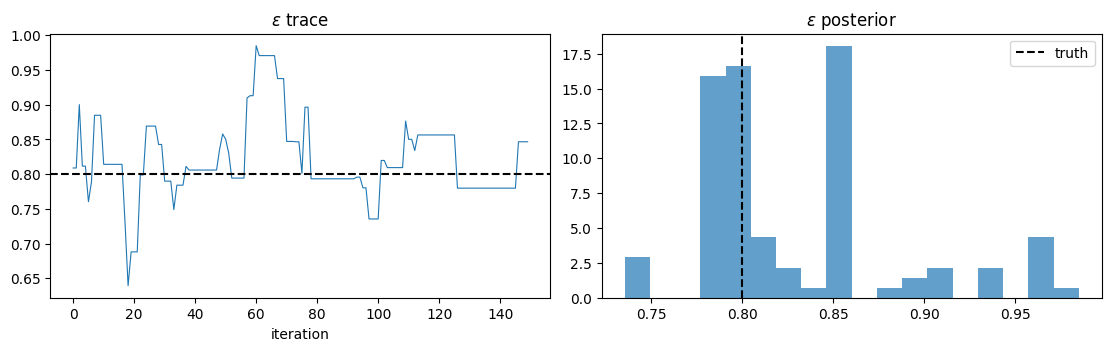

eps posterior: mean 0.828, sd 0.059 (truth 0.80)
tau posterior: mean 0.233, sd 0.014 (truth 0.25)


In [8]:
loglik_fn = inf.make_eps_tau_loglik(
    THETA_STAR, obs_times=times, obs_values=obs, ctrl_values=ctrl, z0=z0, n_particles=400
)
t0 = time.time()
draws, acc = inf.pmmh_eps_tau(loglik_fn, n_steps=150, step=(0.07, 0.07), seed=0)
print("PMMH time %.1fs, acceptance %.2f" % (time.time() - t0, acc))

burn = 50
post = draws[burn:]
fig, axs = plt.subplots(1, 2, figsize=(11, 3.4), constrained_layout=True)
axs[0].plot(draws[:, 0], lw=0.8)
axs[0].axhline(float(THETA_STAR.eps), color="k", ls="--")
axs[0].set_title(r"$\varepsilon$ trace"); axs[0].set_xlabel("iteration")
axs[1].hist(post[:, 0], bins=18, alpha=0.7, density=True)
axs[1].axvline(float(THETA_STAR.eps), color="k", ls="--", label="truth")
axs[1].set_title(r"$\varepsilon$ posterior"); axs[1].legend()
plt.show()

print("eps posterior: mean %.3f, sd %.3f (truth 0.80)" % (post[:, 0].mean(), post[:, 0].std()))
print("tau posterior: mean %.3f, sd %.3f (truth 0.25)" % (post[:, 1].mean(), post[:, 1].std()))

## The historical Dhaka series

We load the monthly cholera mortality for Dhaka, 1891 to 1940, the data behind
the paper's Fig. 2B, together with the census-interpolated population that
enters the model as a known covariate. Overlaying a simulation at the Table 1
parameters, driven by the real population, shows that those parameters generate
epidemics of the observed magnitude and seasonal timing.

Dhaka series: 600 months, deaths mean 590, max 5596


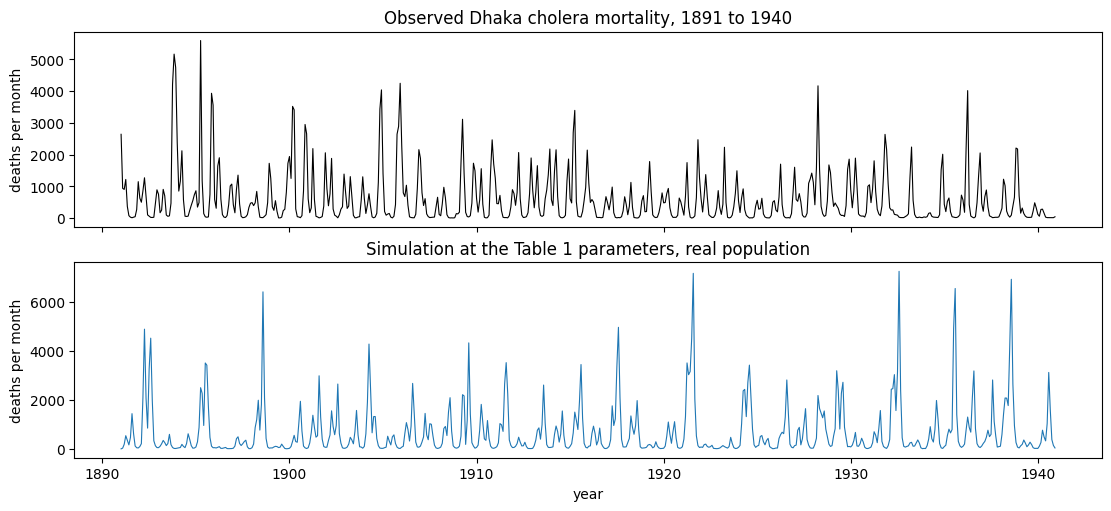

In [9]:
df, dmonths, deaths, pop, dctrl = inf.load_dhaka()
print("Dhaka series: %d months, deaths mean %.0f, max %.0f" % (
    len(dmonths), float(deaths.mean()), float(deaths.max())))

# Simulate at theta* using the real time-varying population.
from numpyro.infer import Predictive
from dynestyx import DiscreteTimeSimulator
z0_real = inf.default_initial_state(float(pop[0]))
with DiscreteTimeSimulator():
    sim = Predictive(inf.cholera_model, num_samples=1, exclude_deterministic=False)(
        jr.PRNGKey(5), **inf.free_params(THETA_STAR), z0=z0_real,
        predict_times=dmonths, ctrl_times=dmonths, ctrl_values=dctrl,
    )
sim_deaths = sim["chol_observations"][0, 0].reshape(-1)

dyear = 1891.0 + dmonths / 12.0
fig, axs = plt.subplots(2, 1, figsize=(11, 5), sharex=True, constrained_layout=True)
axs[0].plot(dyear, deaths, color="k", lw=0.8)
axs[0].set_ylabel("deaths per month")
axs[0].set_title("Observed Dhaka cholera mortality, 1891 to 1940")
axs[1].plot(dyear, sim_deaths, color="C0", lw=0.8)
axs[1].set_ylabel("deaths per month")
axs[1].set_xlabel("year")
axs[1].set_title("Simulation at the Table 1 parameters, real population")
plt.show()

Point estimation from the real series is the hard problem the paper solves.
A single particle-filter pass returns the likelihood at one parameter vector,
and iterated filtering threads many such passes together to climb to the
maximum. The likelihood surface has multiple local maxima and poorly
identified parameter combinations, which is why a naive joint optimization
from a vague start does not recover the generating values. The profile
likelihoods above demonstrate the maximization cleanly on simulated ground
truth, where the answer is known.

## Summary

The cholera state-space model maps onto dynestyx as a continuous-time
stochastic SIRS process with a custom Euler-Maruyama transition, a
heteroscedastic count measurement, and a particle filter for the likelihood.
On simulated data the particle-filter likelihood is maximized at the
generating parameters, profile likelihoods recover the seasonal amplitude, the
environmental noise, and the reservoir strength, and a pseudo-marginal sampler
returns posteriors that cover the truth. The same model generates epidemics
that match the historical Dhaka record in magnitude and seasonal shape.